In [153]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import pickle
import os 

import sys
sys.path.insert(0, '..')
from titan.Experiment import Experiment
from titan.plt_Experiment_summary import titan_plt_summary, titan_plt_summary_temp
from titan.load_and_preprocessing import titan_load_and_preprocessing
import sigmoid_fitting as sp
from titan.processing_DNA import titan_plt_infl
from scipy.ndimage import convolve1d
from sklearn.manifold import TSNE
from sklearn import preprocessing

# Set suitable default colours for colorblind
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import to_hex
wong_palette_10 = [
    (0, 0.45, 0.70),    # Blue
    (0.9, 0.6, 0.0),    # Orange
    (0.0, 0.60, 0.50),  # Bluish Green
    (0.8, 0.4, 0),      # Vermillion
    (0.35, 0.7, 0.9),   # Sky Blue
    (0.8, 0.6, 0.7),    # Reddish Purple
    (0.5, 0.5, 0.5),    # Gray
    (0.95, 0.9, 0.25),  # Yellow
    (0.5, 0.2, 0.5),    # Deep Purple (New)
    (0.6, 0.1, 0.1)     # Dark Red (New)
    # (1.000, 0.627, 0.627),  # Pastel Soft Red/Pink
    # (1.000, 0.757, 0.490),  # Pastel Peach/Orange
    # (0.980, 0.922, 0.549),  # Pastel Lemon Yellow
    # (0.784, 0.941, 0.549),  # Pastel Lime
    # (0.549, 0.941, 0.784),  # Pastel Mint Green
    # (0.549, 0.851, 0.941),  # Pastel Sky Blue
    # (0.659, 0.741, 1.000),  # Pastel Periwinkle
    # (0.816, 0.659, 1.000),  # Pastel Lavender
    # (0.980, 0.659, 0.902),  # Pastel Rose/Magenta
    # (0.941, 0.659, 0.549)   # Pastel Coral
]

mpl.rcParams['axes.prop_cycle'] = cycler(color=[to_hex(i) for i in wong_palette_10])



# 1. Load Data

In [21]:
exp_folder = "/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/Run Data/Transcriptomics"
exp_paths = [Path(exp_folder, name) for name in os.listdir(exp_folder) if name != ".DS_Store"]

In [79]:
dfs = []
for i, path in enumerate(exp_paths):
    print(path)
    dfs.append(pd.read_csv(path, sep="	", encoding="utf-16"))
    # print(dfs[i].shape)
    # print(dfs[i].columns)
    # print(dfs[i].head())
    # print("="*100)

/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/Run Data/Transcriptomics/29072025_row-sample4to9 - Abs Quant.txt
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/Run Data/Transcriptomics/30072025-sample10to15 -raw_data.txt
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/Run Data/Transcriptomics/31072025-sample16-col_raw_data.txt
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/Run Data/Transcriptomics/15072025_sample1to4_rawdata.txt


## 1.1. Data clean up

In [132]:
dfs_cleaned = dfs.copy()
dfs_cleaned[2] = dfs_cleaned[2].set_index('Cycle\Fluorescence').T.reset_index().rename(columns={"index":"Fluorescence\Cycle"}).rename_axis(None, axis=1)
dfs_cleaned[3] = dfs_cleaned[3].iloc[:,:dfs_cleaned[2].shape[1]]
for i in range(1,4):
    dfs_cleaned[i].columns = dfs_cleaned[0].columns

<>:2: SyntaxWarning: invalid escape sequence '\F'
<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\F'
<>:2: SyntaxWarning: invalid escape sequence '\C'
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_70364/3399384182.py:2: SyntaxWarning: invalid escape sequence '\F'
  dfs_cleaned[2] = dfs_cleaned[2].set_index('Cycle\Fluorescence').T.reset_index().rename(columns={"index":"Fluorescence\Cycle"}).rename_axis(None, axis=1)
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_70364/3399384182.py:2: SyntaxWarning: invalid escape sequence '\C'
  dfs_cleaned[2] = dfs_cleaned[2].set_index('Cycle\Fluorescence').T.reset_index().rename(columns={"index":"Fluorescence\Cycle"}).rename_axis(None, axis=1)


In [102]:
stacked_df = dfs_cleaned[0].iloc[:,1:36].copy()
stacked_df["data"] = str(exp_paths[0]).replace(exp_folder,"")
for i in range(1, len(dfs_cleaned)):
    df = dfs_cleaned[i].iloc[:,1:36].copy()
    df.columns = [str(a) for a in list(range(1,36))]
    df["data"] = str(exp_paths[i]).replace(exp_folder,"")
    stacked_df = pd.concat([stacked_df, df])
print(stacked_df.shape)

(384, 36)


# 2. Data Viz

## 2.1. Initial Viz

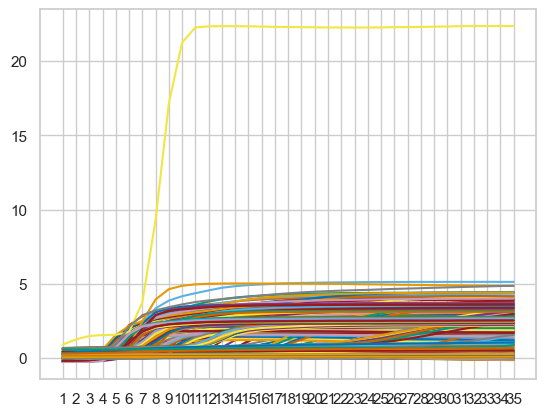

In [155]:
plt.plot(stacked_df.iloc[:,0:35].T)
plt.show()

/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_70364/4123334647.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(AC_tsne[:, 0], AC_tsne[:, 1], s=20, c=wong_palette_10[i])


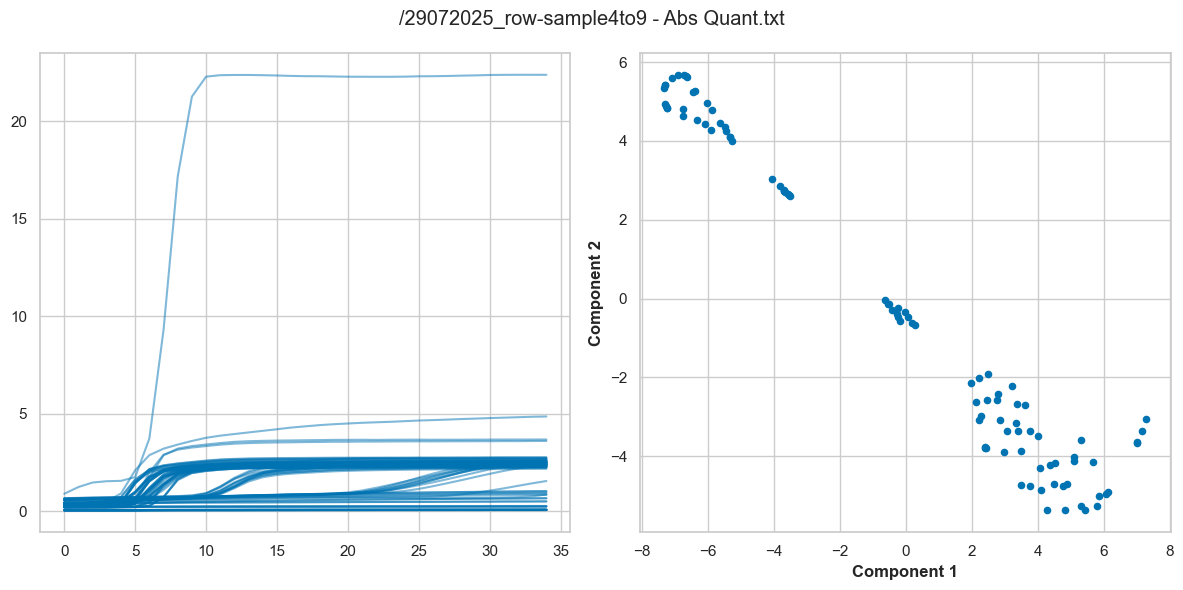

/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_70364/4123334647.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(AC_tsne[:, 0], AC_tsne[:, 1], s=20, c=wong_palette_10[i])


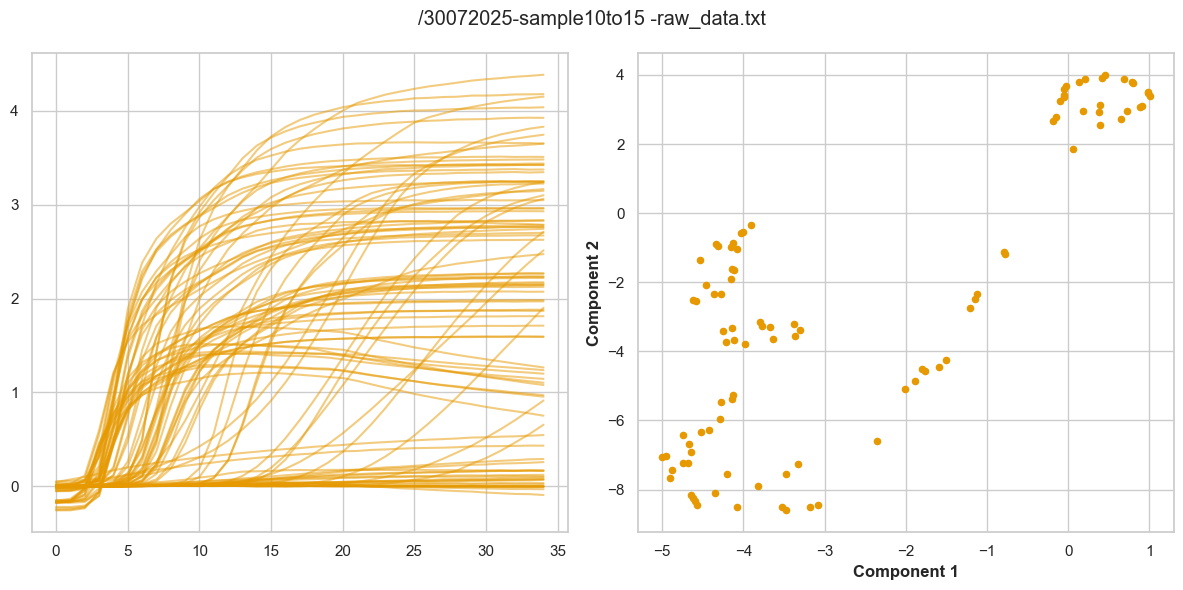

/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_70364/4123334647.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(AC_tsne[:, 0], AC_tsne[:, 1], s=20, c=wong_palette_10[i])


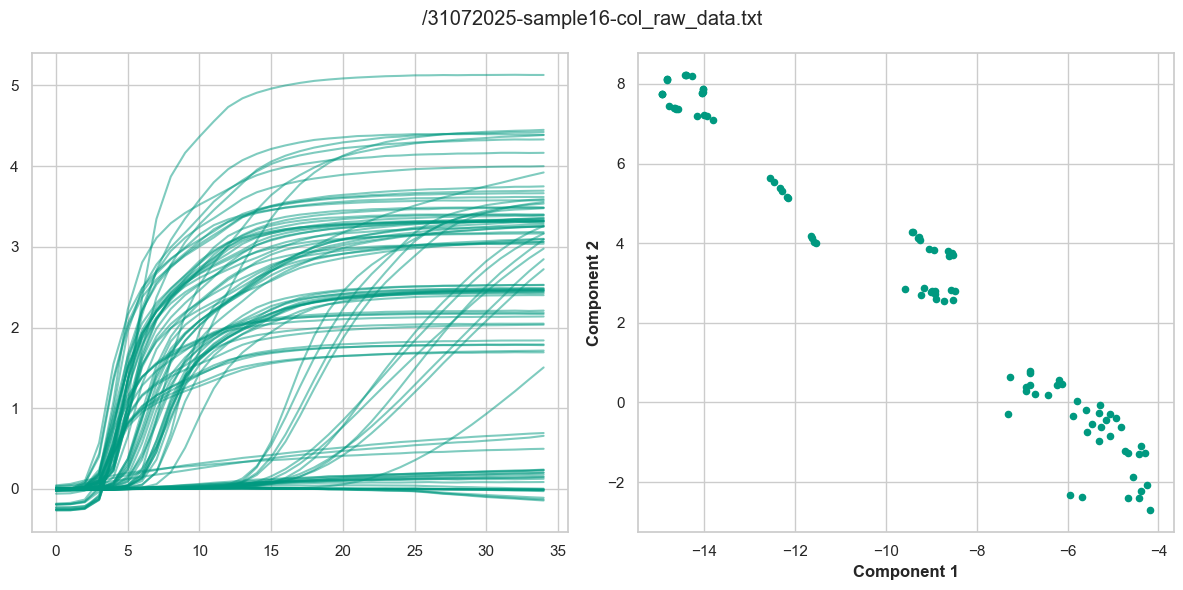

/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_70364/4123334647.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[1].scatter(AC_tsne[:, 0], AC_tsne[:, 1], s=20, c=wong_palette_10[i])


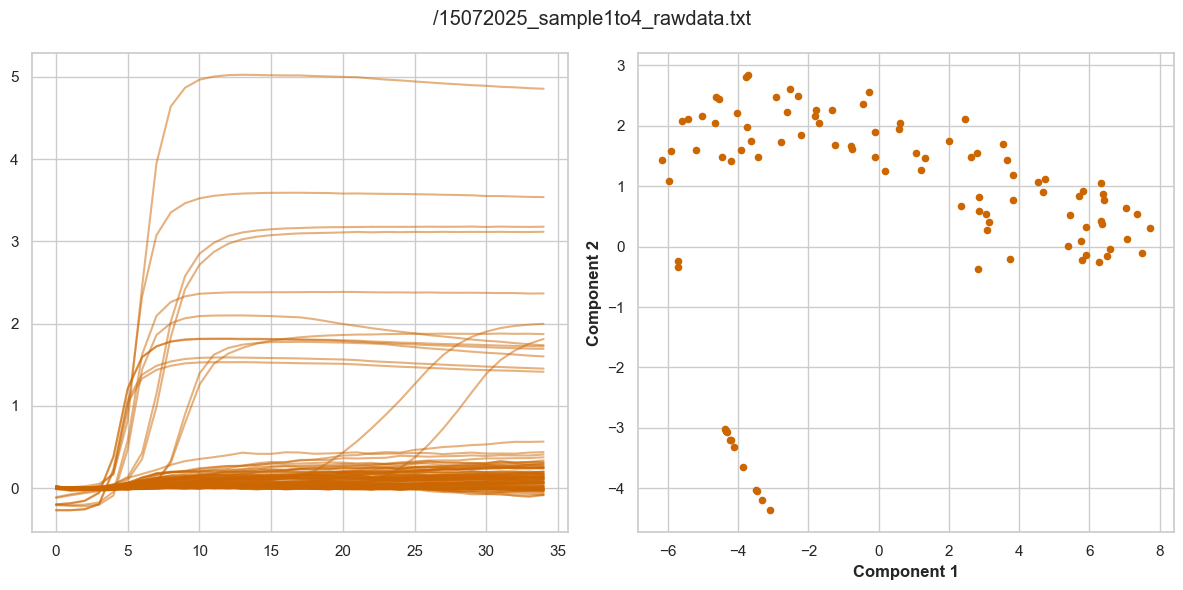

In [156]:
y = stacked_df.data.values
X = stacked_df.iloc[:,0:35].values
for i, label in enumerate(np.unique(y)):
    mask = y == label

    AC_tsne = TSNE(n_components=2, init='random', learning_rate='auto', random_state=0).fit_transform(X[mask, :])
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    ax[0].plot(X[mask, :].T, c=wong_palette_10[i], alpha=0.5)

    ax[1].scatter(AC_tsne[:, 0], AC_tsne[:, 1], s=20, c=wong_palette_10[i])
    ax[1].set_xlabel('Component 1', fontweight='bold')
    ax[1].set_ylabel('Component 2', fontweight='bold')
    # ax.set_title('t-SNE Visualization - Moving Average (25)', fontsize=24, fontweight='bold')
    # ax.grid(True, alpha=0.3)
    
    fig.suptitle(str(exp_paths[i]).replace(exp_folder,""))
    plt.tight_layout()
    plt.show()

/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_70364/1392539455.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(AC_tsne[mask, 0], AC_tsne[mask, 1],


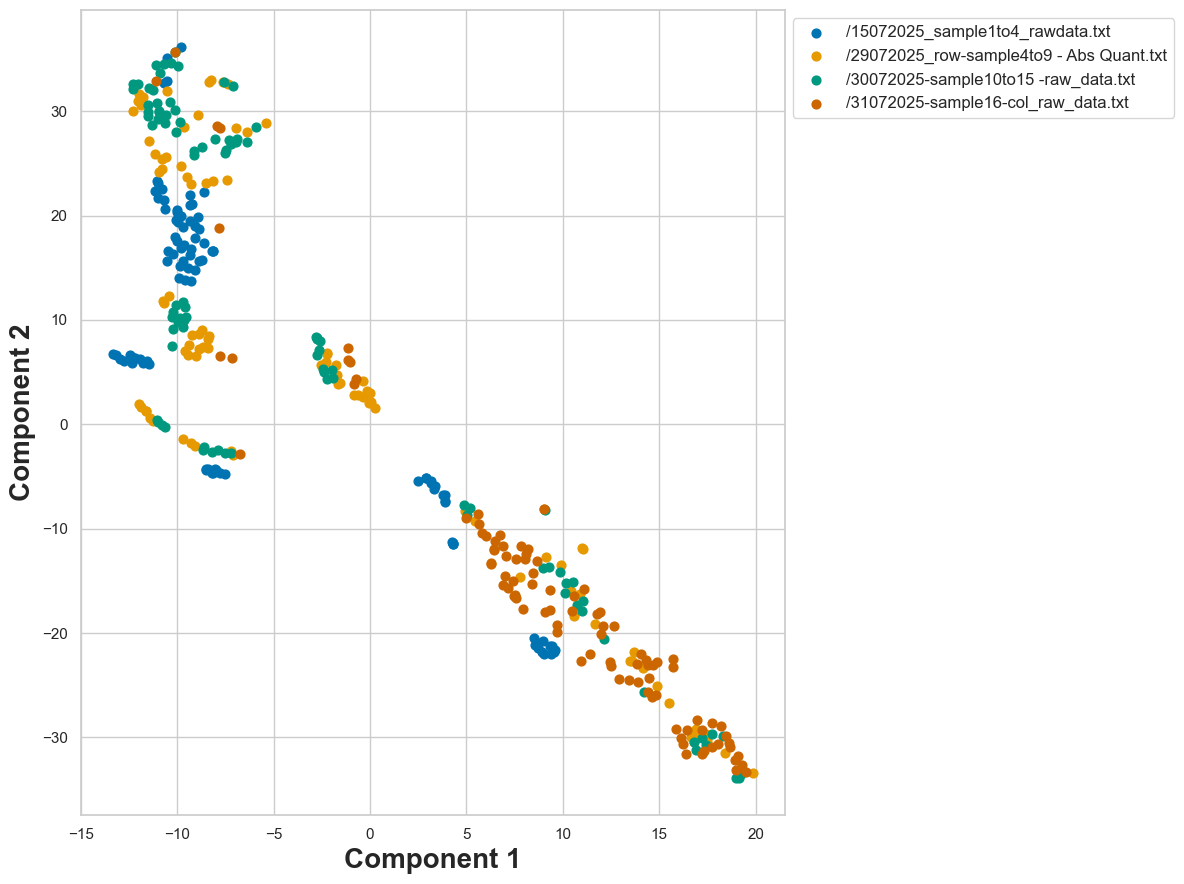

In [157]:
fig, ax = plt.subplots(figsize=(12, 9))
y = stacked_df.data.values
X = stacked_df.iloc[:,0:35].values


AC_tsne = TSNE(n_components=2, init='random', learning_rate='auto', random_state=0).fit_transform(X)

for i, label in enumerate(np.unique(y)):
    mask = y == label
    ax.scatter(AC_tsne[mask, 0], AC_tsne[mask, 1],
               s=40, c=wong_palette_10[i], label=f"{label}")

ax.set_xlabel('Component 1', fontsize=20, fontweight='bold')
ax.set_ylabel('Component 2', fontsize=20, fontweight='bold')
# ax.set_title('t-SNE Visualization - Moving Average (25)', fontsize=24, fontweight='bold')
# ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

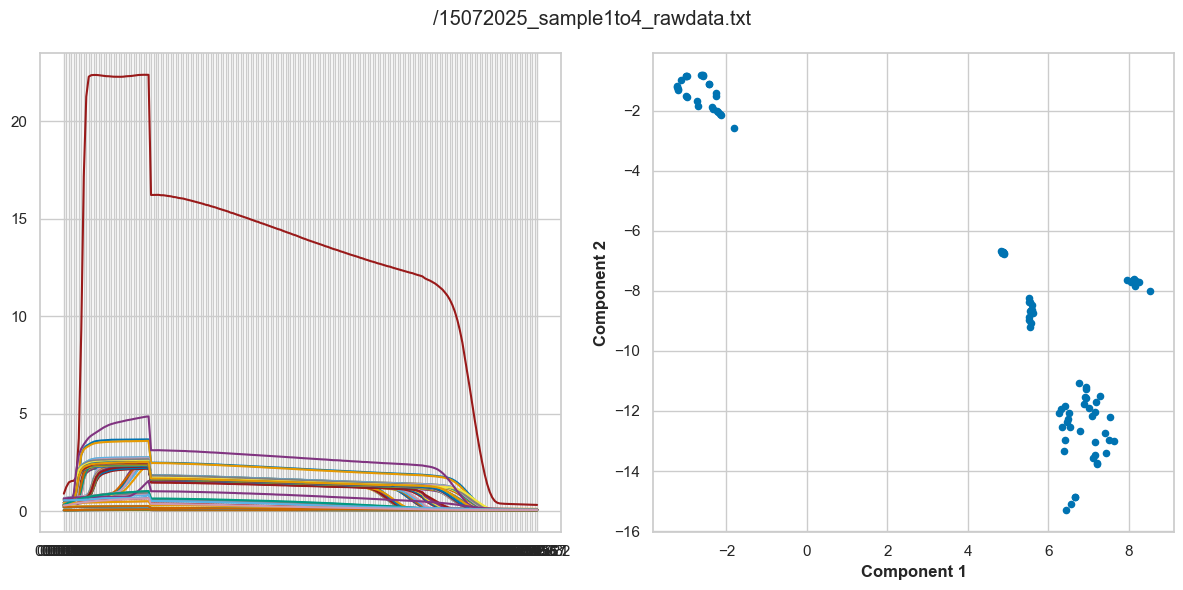

In [158]:

AC_tsne = TSNE(n_components=2, init='random', learning_rate='auto', random_state=0).fit_transform(dfs[3].iloc[:,1:])
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].plot(dfs[3].set_index(dfs[3].columns[0]).T)

ax[1].scatter(AC_tsne[:, 0], AC_tsne[:, 1], s=20)
ax[1].set_xlabel('Component 1', fontweight='bold')
ax[1].set_ylabel('Component 2', fontweight='bold')
# ax.set_title('t-SNE Visualization - Moving Average (25)', fontsize=24, fontweight='bold')
# ax.grid(True, alpha=0.3)

fig.suptitle(str(exp_paths[3]).replace(exp_folder,""))
plt.tight_layout()
plt.show()

## 2.2. Grouped Viz

0 /29072025_row-sample4to9 - Abs Quant.txt


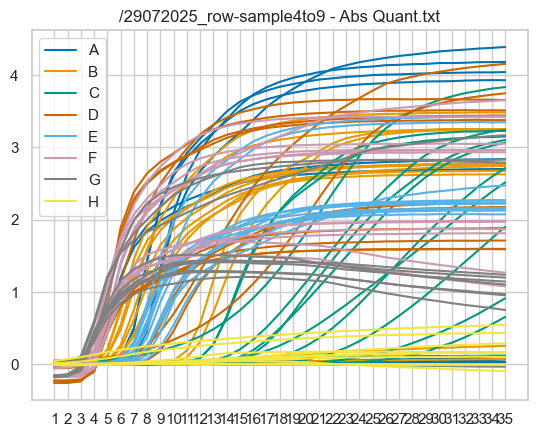

1 /30072025-sample10to15 -raw_data.txt


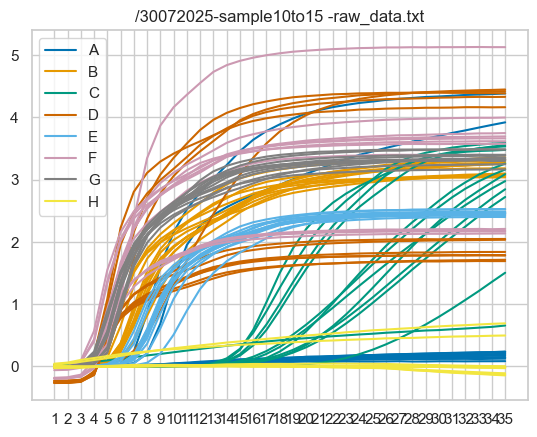

2 /31072025-sample16-col_raw_data.txt


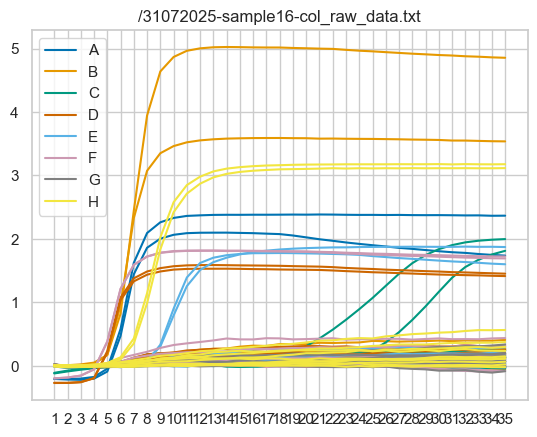

3 /15072025_sample1to4_rawdata.txt


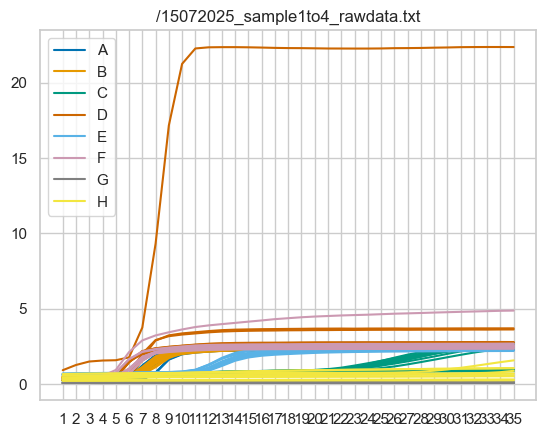

In [160]:
for fileindex, df in enumerate(dfs_cleaned):
    print(fileindex, str(exp_paths[fileindex]).replace(exp_folder,""))
    for i in range(8):
        data = df.iloc[i*12:(i+1)*12, :].set_index(r'Fluorescence\Cycle').T
        plt.plot(data, color=f"C{i}", label=chr(i+65))

    handles, labels = plt.gca().get_legend_handles_labels()
    unique_legend = dict(zip(labels, handles))
    plt.title(str(exp_paths[fileindex]).replace(exp_folder,""))
    plt.legend(unique_legend.values(), unique_legend.keys())
    plt.show()

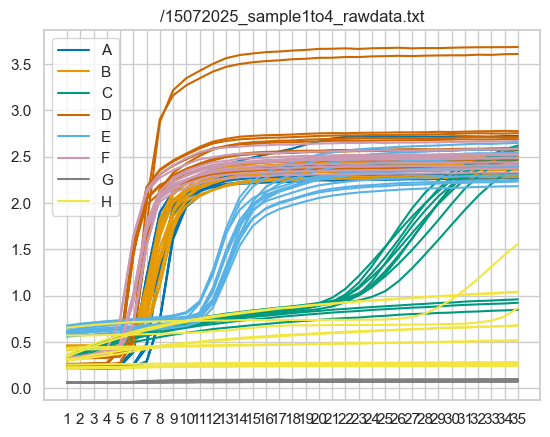

In [161]:

for i in range(8):
    data = dfs_cleaned[3].iloc[i*12:(i+1)*12, :].set_index(r'Fluorescence\Cycle')
    data = data[data["35"] < 4]
    data = data.T
    plt.plot(data, color=f"C{i}", label=chr(i+65))

handles, labels = plt.gca().get_legend_handles_labels()
unique_legend = dict(zip(labels, handles))
plt.title(str(exp_paths[fileindex]).replace(exp_folder,""))
plt.legend(unique_legend.values(), unique_legend.keys())
plt.show()

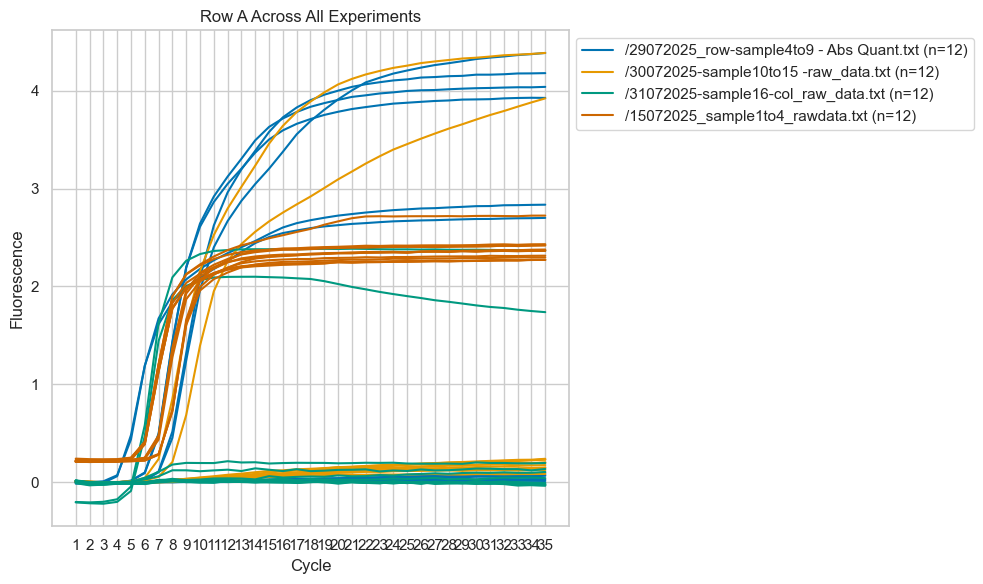

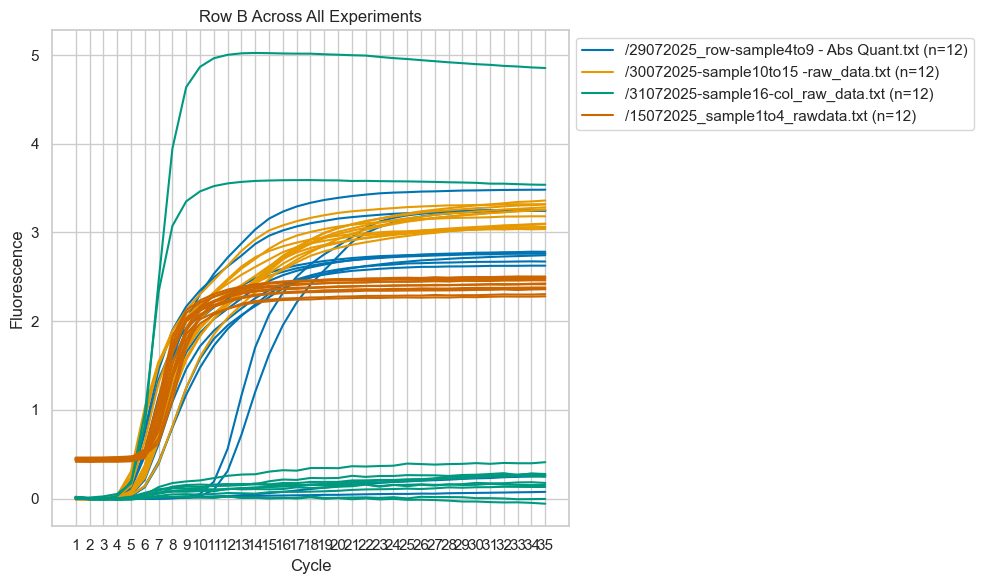

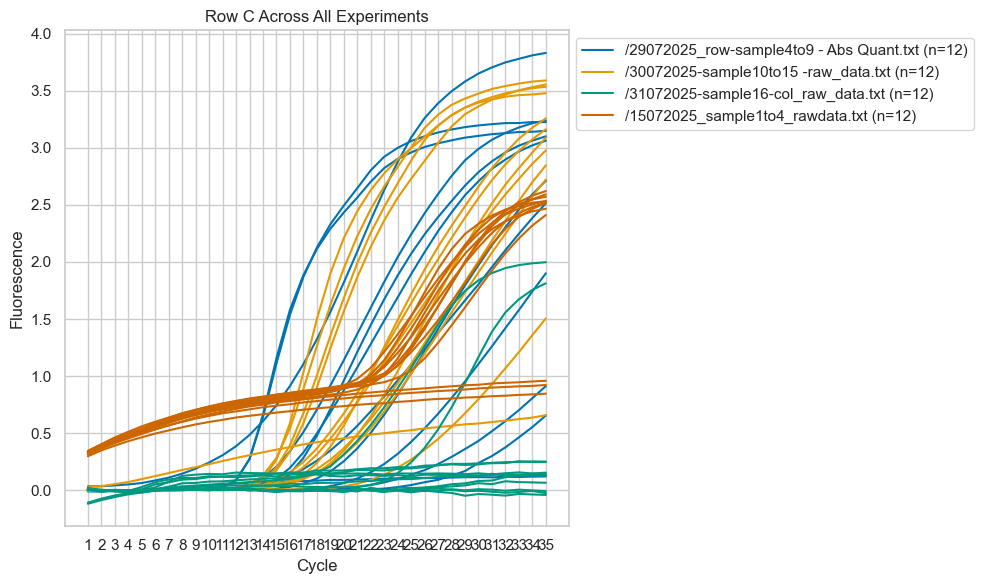

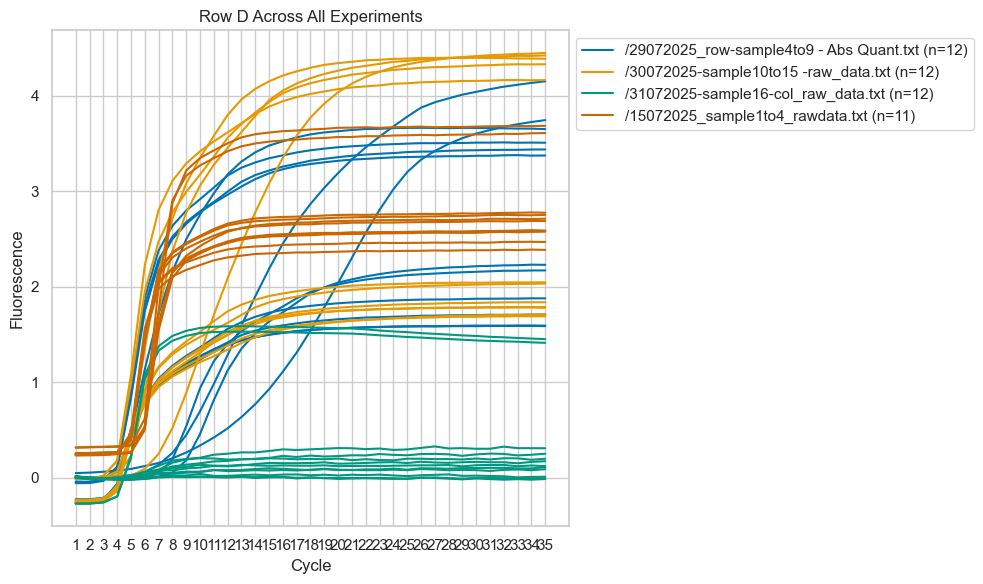

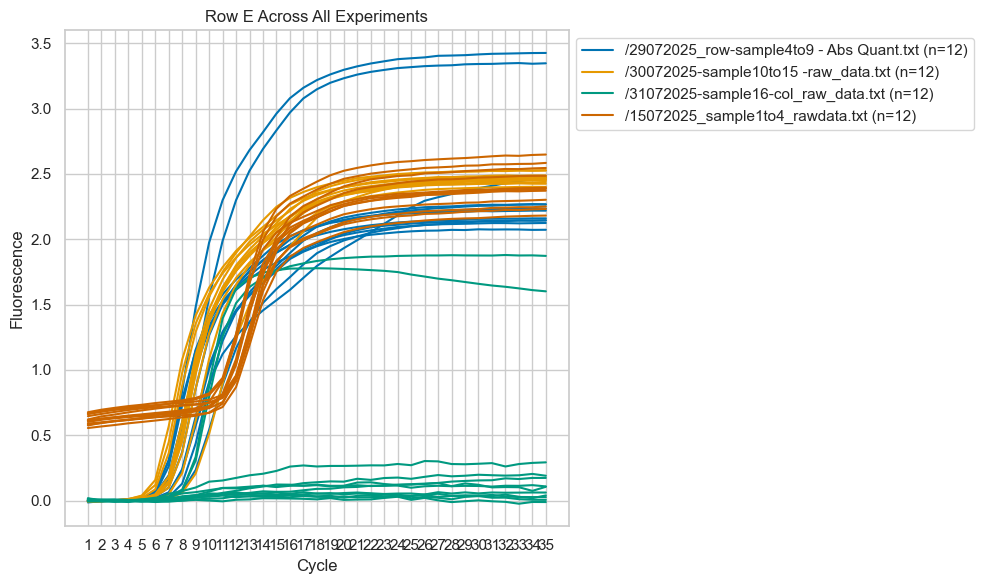

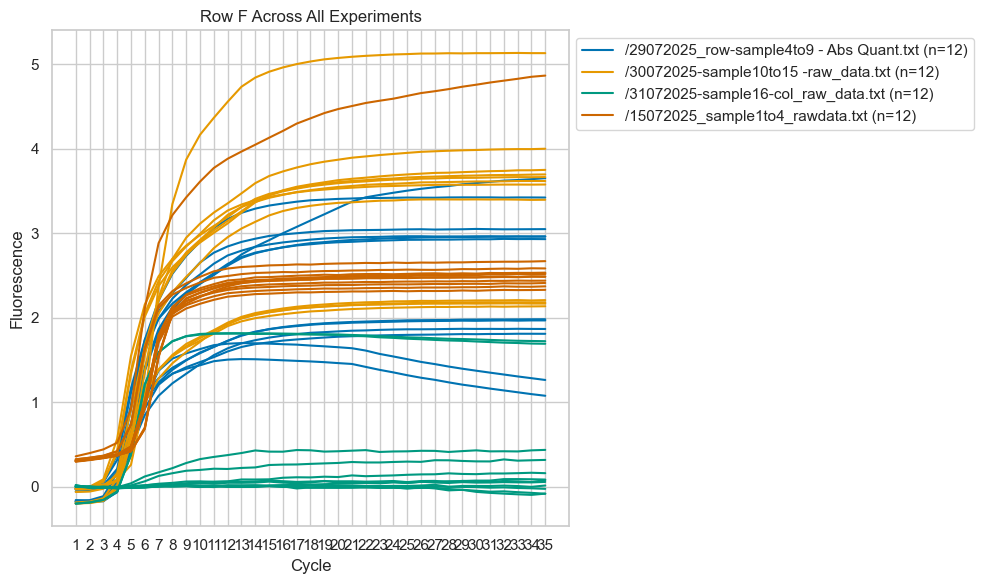

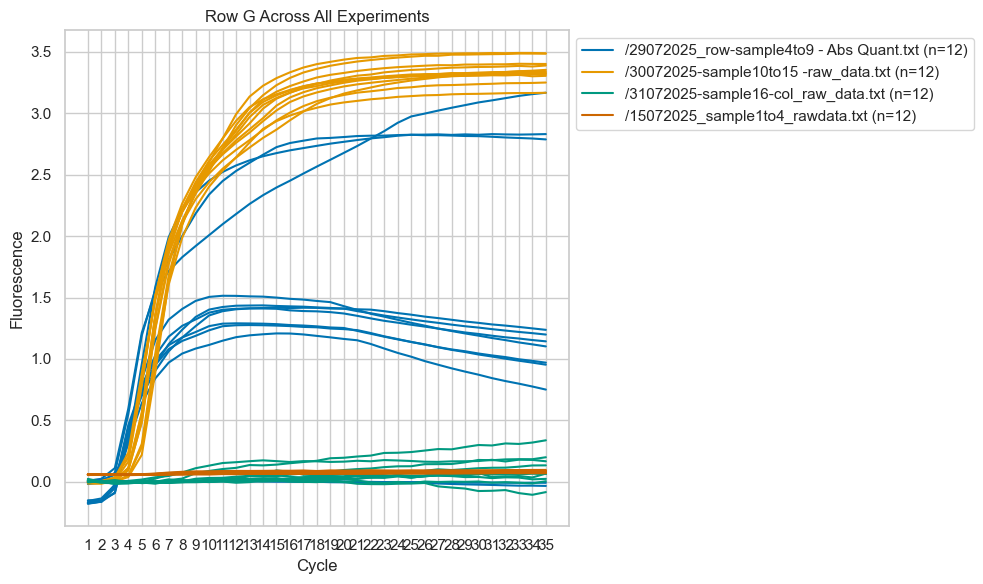

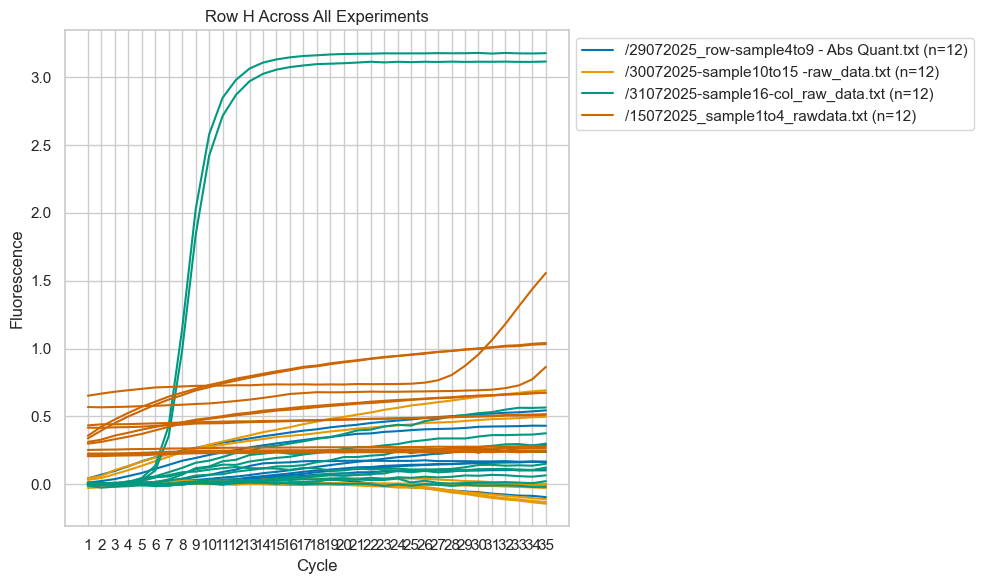

In [162]:
for i in range(8):
    plt.figure(figsize=(10, 6)) # Create a new figure for each row group
    row_letter = chr(i + 65)
    
    # Inner loop: Iterate through all the dataframes for the current row
    for fileindex, df in enumerate(dfs_cleaned):
        # Extract the file name to use in the legend
        file_name = str(exp_paths[fileindex]).replace(exp_folder, "")
        
        # Isolate the 12 wells for the current row
        data = df.iloc[i*12:(i+1)*12, :].set_index(r'Fluorescence\Cycle')
        data = data[data["35"] < 20]
        data = data.T
        
        # Plot the data. We use 'fileindex' for the color so all 12 lines from 
        # the same file share the same color.
        plt.plot(data, color=f"C{fileindex}", label=f"{file_name} (n={data.shape[1]})")

    # Clean up duplicate legend entries (since each file plots 12 lines)
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_legend = dict(zip(labels, handles))
    
    # Formatting the plot
    plt.title(f"Row {row_letter} Across All Experiments")
    plt.xlabel("Cycle")
    plt.ylabel("Fluorescence")
    
    # Place legend outside the plot area if file names are long
    plt.legend(unique_legend.values(), unique_legend.keys(), loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show the completed plot for row 'i' before moving to the next 'i'
    plt.tight_layout()
    plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_70364/4094538581.py:3: SyntaxWarning: invalid escape sequence '\C'
  plt.plot(dfs[0].iloc[np.arange(i,96,12),:].set_index('Fluorescence\Cycle').T, color=f"C{i}", label=i)


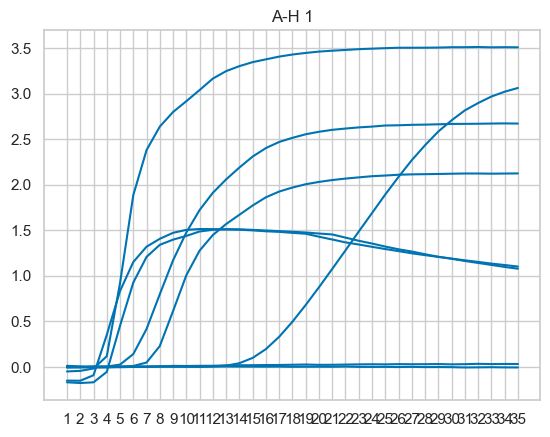

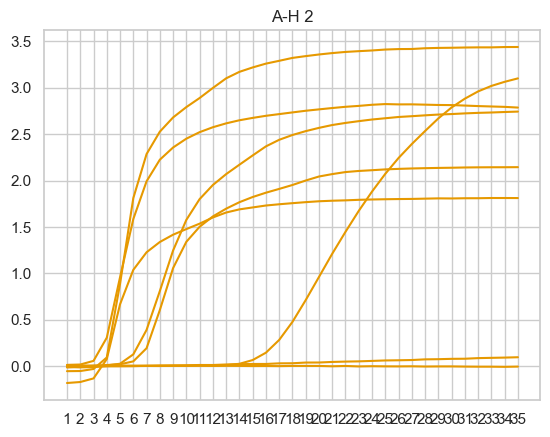

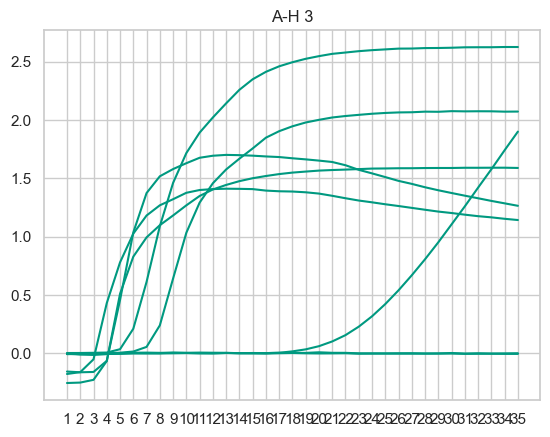

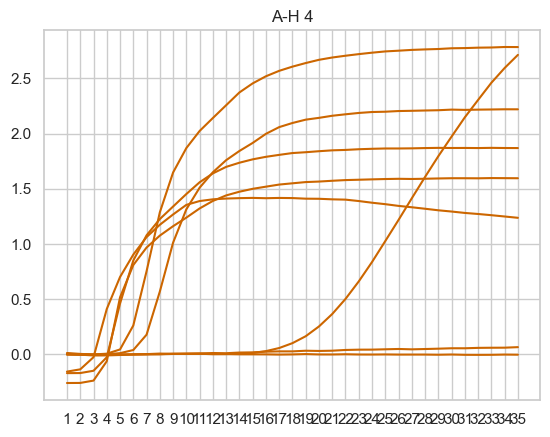

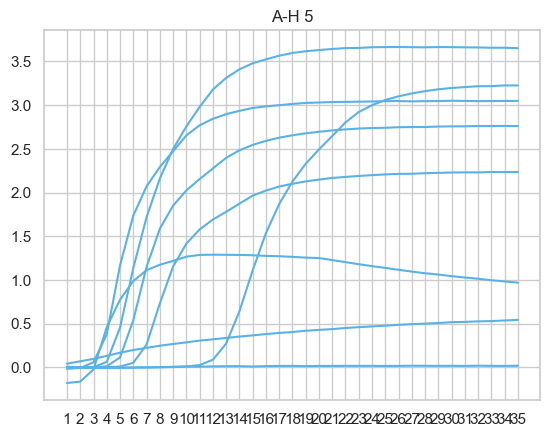

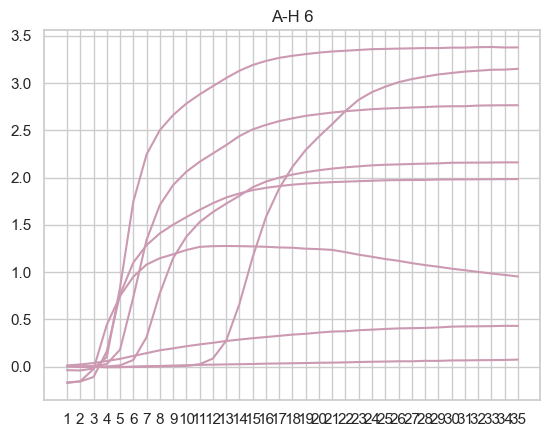

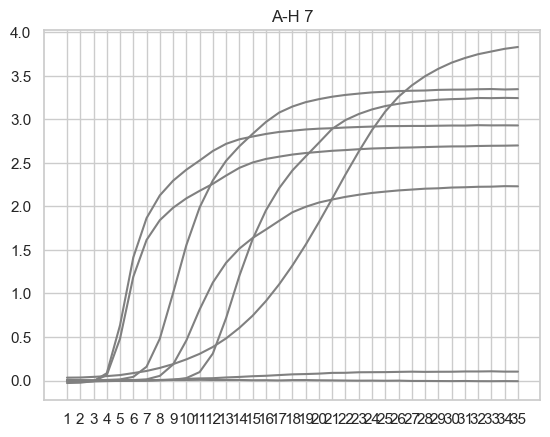

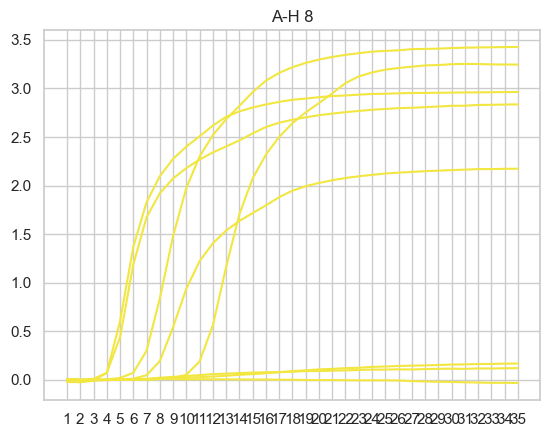

In [163]:
    
for i in range(8):
    plt.title(f"A-H {i+1}")
    plt.plot(dfs[0].iloc[np.arange(i,96,12),:].set_index('Fluorescence\Cycle').T, color=f"C{i}", label=i)
    plt.show()


In [164]:
dfs_cleaned[0]

,Fluorescence\Cycle,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,A1 SYBR Green I,0.007600,0.001206,-0.003716,-0.001995,-0.003314,0.000201,0.002259,0.005719,0.011207,...,0.030597,0.029318,0.029955,0.031231,0.028023,0.029901,0.033671,0.031045,0.032336,0.032090
1,A2 SYBR Green I,0.003899,0.003516,0.002543,0.001028,0.001124,0.000495,0.003802,0.004068,0.006460,...,0.063091,0.065719,0.072942,0.074736,0.078562,0.079689,0.086254,0.089276,0.091987,0.095833
2,A3 SYBR Green I,-0.002146,0.000696,0.002149,0.000694,0.000073,0.002256,0.000930,-0.000488,0.002073,...,0.001636,0.002062,-0.000168,0.000356,0.004024,-0.001013,0.001726,-0.000853,0.000461,0.001960
3,A4 SYBR Green I,0.005078,0.001425,-0.003528,-0.001683,0.000149,0.000347,0.002842,0.001509,0.004328,...,0.049448,0.046192,0.049004,0.052126,0.055955,0.055796,0.059473,0.060667,0.061221,0.066023
4,A5 SYBR Green I,0.002540,0.003468,-0.000096,-0.001820,-0.002031,-0.003459,0.001279,0.003318,0.007968,...,0.017789,0.019964,0.019066,0.018344,0.018928,0.017413,0.020258,0.018449,0.017774,0.019793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,H8 SYBR Green I,0.007937,0.000794,-0.002715,-0.001431,0.004076,0.004653,0.008404,0.012295,0.014031,...,0.142130,0.145603,0.148191,0.152573,0.156353,0.158902,0.162210,0.163150,0.166302,0.167768
92,H9 SYBR Green I,0.006124,0.002250,-0.000130,-0.002694,0.001655,0.004198,0.007151,0.011070,0.019600,...,0.144555,0.149074,0.149386,0.155442,0.156797,0.161002,0.161237,0.161618,0.164821,0.162690
93,H10 SYBR Green I,0.008231,0.002007,0.002870,0.008700,0.009193,0.013819,0.019050,0.026075,0.031635,...,0.216346,0.227223,0.236316,0.245534,0.254122,0.261247,0.269742,0.276447,0.285823,0.288977
94,H11 SYBR Green I,0.008035,-0.000238,-0.002376,-0.002254,0.000923,-0.000518,0.000780,0.002771,0.008638,...,-0.029146,-0.038490,-0.045786,-0.052992,-0.058297,-0.068729,-0.076172,-0.083546,-0.085563,-0.094935
